# Part A — Data Preparation
## Market Sentiment Analysis: Fear/Greed Index × Hyperliquid Trader Data
---
This notebook covers:
1. Loading & documenting both datasets
2. Cleaning, deduplication, missing value analysis
3. Timestamp conversion & alignment by date
4. Feature engineering: daily PnL, win rate, trade size, leverage proxy, long/short ratio

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Datasets & Document Structure

In [2]:
# Load Fear & Greed Index
fgi = pd.read_csv('fear_greed_index.csv')
print("=" * 60)
print("FEAR & GREED INDEX")
print("=" * 60)
print(f"Shape: {fgi.shape[0]} rows × {fgi.shape[1]} columns")
print(f"Columns: {fgi.columns.tolist()}")
print(f"\nData Types:\n{fgi.dtypes}")
print(f"\nMissing Values:\n{fgi.isnull().sum()}")
print(f"\nDuplicates: {fgi.duplicated().sum()}")
print(f"\nFirst 5 rows:")
fgi.head()

FEAR & GREED INDEX
Shape: 2644 rows × 4 columns
Columns: ['timestamp', 'value', 'classification', 'date']

Data Types:
timestamp          int64
value              int64
classification    object
date              object
dtype: object

Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicates: 0

First 5 rows:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [3]:
# Load Historical Trader Data
hist = pd.read_csv('historical_data.csv')
print("=" * 60)
print("HISTORICAL TRADER DATA")
print("=" * 60)
print(f"Shape: {hist.shape[0]} rows × {hist.shape[1]} columns")
print(f"Columns: {hist.columns.tolist()}")
print(f"\nData Types:\n{hist.dtypes}")
print(f"\nMissing Values:\n{hist.isnull().sum()}")
print(f"\nDuplicates: {hist.duplicated().sum()}")
print(f"\nUnique Accounts: {hist['Account'].nunique()}")
print(f"Unique Coins: {hist['Coin'].nunique()}")
print(f"\nFirst 5 rows:")
hist.head()

HISTORICAL TRADER DATA
Shape: 211224 rows × 16 columns
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Data Types:
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction H


Duplicates: 0

Unique Accounts: 32
Unique Coins: 246

First 5 rows:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## 2. Timestamp Conversion & Alignment

In [4]:
# Convert FGI date
fgi['date'] = pd.to_datetime(fgi['date'])
fgi = fgi.rename(columns={'value': 'fgi_value', 'classification': 'sentiment'})
fgi = fgi.sort_values('date').reset_index(drop=True)
print(f"FGI date range: {fgi['date'].min().date()} to {fgi['date'].max().date()}")
print(f"Sentiment distribution:\n{fgi['sentiment'].value_counts()}")
fgi.head()

FGI date range: 2018-02-01 to 2025-05-02
Sentiment distribution:
sentiment
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


,timestamp,fgi_value,sentiment,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
# Convert Historical timestamps
hist['datetime_ist'] = pd.to_datetime(hist['Timestamp IST'], format='%d-%m-%Y %H:%M')
hist['date'] = hist['datetime_ist'].dt.date
hist['date'] = pd.to_datetime(hist['date'])
print(f"Historical date range: {hist['date'].min().date()} to {hist['date'].max().date()}")
print(f"Trades per day (avg): {len(hist) / hist['date'].nunique():.1f}")
hist.head()

Historical date range: 2023-05-01 to 2025-05-01
Trades per day (avg): 440.1


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,datetime_ist,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02


In [6]:
# Merge datasets on date
merged = hist.merge(fgi[['date', 'fgi_value', 'sentiment']], on='date', how='left')
print(f"Merged shape: {merged.shape}")
print(f"Rows with sentiment data: {merged['sentiment'].notna().sum()} / {len(merged)}")
print(f"Rows without sentiment data (dropped): {merged['sentiment'].isna().sum()}")
merged = merged.dropna(subset=['sentiment'])
print(f"Final merged shape: {merged.shape}")
merged.head()

Merged shape: (211224, 20)
Rows with sentiment data: 211218 / 211224
Rows without sentiment data (dropped): 6


Final merged shape: (211218, 20)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,datetime_ist,date,fgi_value,sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed


## 3. Feature Engineering — Key Metrics

In [7]:
# --- Classify trade outcomes ---
# A trade with Closed PnL > 0 is a win, < 0 is a loss, == 0 is neutral (opening)
merged['is_closing_trade'] = merged['Closed PnL'] != 0
merged['is_win'] = merged['Closed PnL'] > 0
merged['is_loss'] = merged['Closed PnL'] < 0

# --- Long / Short classification ---
long_dirs = ['Open Long', 'Close Long', 'Buy']
short_dirs = ['Open Short', 'Close Short', 'Sell']
merged['position_type'] = np.where(merged['Direction'].isin(long_dirs), 'Long',
                           np.where(merged['Direction'].isin(short_dirs), 'Short', 'Other'))

# --- Net PnL per trade (PnL minus fees) ---
merged['net_pnl'] = merged['Closed PnL'] - merged['Fee']

print("Feature engineering complete!")
print(f"Position type distribution:\n{merged['position_type'].value_counts()}")
print(f"\nDirection distribution:\n{merged['Direction'].value_counts()}")

Feature engineering complete!
Position type distribution:
position_type
Long     115289
Short     95650
Other       279
Name: count, dtype: int64

Direction distribution:
Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36007
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64


In [8]:
# ======== DAILY METRICS PER TRADER ========
daily_trader = merged.groupby(['date', 'Account', 'sentiment', 'fgi_value']).agg(
    total_trades=('Coin', 'count'),
    total_pnl=('Closed PnL', 'sum'),
    net_pnl=('net_pnl', 'sum'),
    total_fees=('Fee', 'sum'),
    avg_trade_size_usd=('Size USD', 'mean'),
    total_volume_usd=('Size USD', 'sum'),
    wins=('is_win', 'sum'),
    losses=('is_loss', 'sum'),
    closing_trades=('is_closing_trade', 'sum'),
    num_longs=('position_type', lambda x: (x == 'Long').sum()),
    num_shorts=('position_type', lambda x: (x == 'Short').sum()),
    max_trade_size=('Size USD', 'max'),
    unique_coins=('Coin', 'nunique'),
).reset_index()

# Win rate (only for days with closing trades)
daily_trader['win_rate'] = daily_trader['wins'] / daily_trader['closing_trades'].replace(0, np.nan)
# Long/Short ratio
daily_trader['long_short_ratio'] = daily_trader['num_longs'] / daily_trader['num_shorts'].replace(0, np.nan)
# Leverage proxy: max trade size / avg trade size
daily_trader['leverage_proxy'] = daily_trader['max_trade_size'] / daily_trader['avg_trade_size_usd'].replace(0, np.nan)

print(f"Daily trader metrics shape: {daily_trader.shape}")
print(f"Date range: {daily_trader['date'].min().date()} to {daily_trader['date'].max().date()}")
daily_trader.head(10)

Daily trader metrics shape: (2340, 20)
Date range: 2023-05-01 to 2025-05-01


,date,Account,sentiment,fgi_value,total_trades,total_pnl,net_pnl,total_fees,avg_trade_size_usd,total_volume_usd,wins,losses,closing_trades,num_longs,num_shorts,max_trade_size,unique_coins,win_rate,long_short_ratio,leverage_proxy
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,63.0,3,0.000000,0.000000,0.000000,159.000000,477.00,0,0,0,3,0,183.53,1,NaN,NaN,1.154277
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme Greed,75.0,9,0.000000,-12.501455,12.501455,5556.203333,50005.83,0,0,0,7,2,24370.62,2,NaN,3.50,4.386200
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,72.0,11,-205.434737,-233.735568,28.300831,10291.213636,113203.35,4,2,6,7,4,25252.56,4,0.666667,1.75,2.453798
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,70.0,2,-24.632034,-27.284523,2.652489,5304.975000,10609.95,0,2,2,0,2,6667.75,1,0.000000,0.00,1.256886
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,67.0,3,0.000000,-3.837189,3.837189,5116.256667,15348.77,0,0,0,3,0,6036.19,1,NaN,NaN,1.179806
5,2023-12-17,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,73.0,14,304.982785,275.913286,29.069499,8305.572857,116278.02,7,4,11,14,0,30572.93,3,0.636364,NaN,3.681014
6,2023-12-18,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,65.0,2,0.000000,-7.791045,7.791045,15582.090000,31164.18,0,0,0,2,0,31146.76,1,NaN,NaN,1.998882
7,2023-12-19,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,73.0,15,1000.538612,977.638016,22.900596,6106.827333,91602.41,10,0,10,15,0,27346.85,2,1.000000,NaN,4.478078
8,2023-12-20,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,74.0,18,162.732282,127.323095,35.409187,7868.710556,141636.79,8,0,8,18,0,23605.58,2,1.000000,NaN,2.999930
9,2023-12-21,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,70.0,49,537.211402,505.902933,31.308469,2555.795306,125233.97,26,1,27,49,0,6308.51,1,0.962963,NaN,2.468316


In [9]:
# ======== DAILY AGGREGATE METRICS (ALL TRADERS) ========
daily_agg = daily_trader.groupby(['date', 'sentiment', 'fgi_value']).agg(
    total_trades=('total_trades', 'sum'),
    total_pnl=('total_pnl', 'sum'),
    net_pnl=('net_pnl', 'sum'),
    avg_trade_size=('avg_trade_size_usd', 'mean'),
    total_volume=('total_volume_usd', 'sum'),
    active_traders=('Account', 'nunique'),
    avg_win_rate=('win_rate', 'mean'),
    avg_long_short_ratio=('long_short_ratio', 'mean'),
).reset_index()

print(f"Daily aggregate shape: {daily_agg.shape}")
daily_agg.describe()

Daily aggregate shape: (479, 11)


,date,fgi_value,total_trades,total_pnl,net_pnl,avg_trade_size,total_volume,active_traders,avg_win_rate,avg_long_short_ratio
count,479,479.000000,479.000000,479.000000,479.000000,479.000000,4.790000e+02,479.000000,419.000000,390.000000
mean,2024-08-25 13:55:44.467640832,60.054280,440.956159,21408.114717,20894.859584,6886.868036,2.486636e+06,4.885177,0.833052,1.621694
min,2023-05-01 00:00:00,10.000000,1.000000,-419020.225731,-426362.306573,0.110000,1.100000e-01,1.000000,0.000000,0.000000
25%,2024-04-22 12:00:00,48.000000,18.500000,5.357891,-0.340628,3459.714689,9.853497e+04,1.000000,0.774598,0.119283
50%,2024-08-25 00:00:00,67.000000,68.000000,1118.387284,1002.214905,5529.415556,3.272180e+05,2.000000,0.932243,0.772885
75%,2025-01-01 12:00:00,74.000000,521.000000,10629.856994,10514.807386,8969.097629,1.649486e+06,8.500000,1.000000,1.998255
max,2025-05-01 00:00:00,94.000000,6246.000000,616413.032233,615372.468191,67612.967654,5.591462e+07,20.000000,1.000000,28.686818
std,NaN,18.687621,810.351623,71930.154661,71576.499753,5796.434811,6.290452e+06,4.910642,0.243392,2.689787


## 4. Data Quality Summary & Save

SUMMARY BY SENTIMENT CATEGORY
               days  avg_daily_pnl  avg_daily_trades  avg_win_rate  \
sentiment                                                            
Extreme Fear     14       52793.59           1528.57          0.67   
Extreme Greed   114       23817.29            350.81          0.88   
Fear             91       36891.82            679.53          0.88   
Greed           193       11140.57            260.64          0.81   
Neutral          67       19297.32            562.48          0.79   

               avg_trade_size  avg_volume  
sentiment                                  
Extreme Fear          5520.25  8177447.25  
Extreme Greed         5820.76  1091799.69  
Fear                  7298.14  5311261.43  
Greed                 7152.92  1495246.09  
Neutral               7661.43  2690180.05  


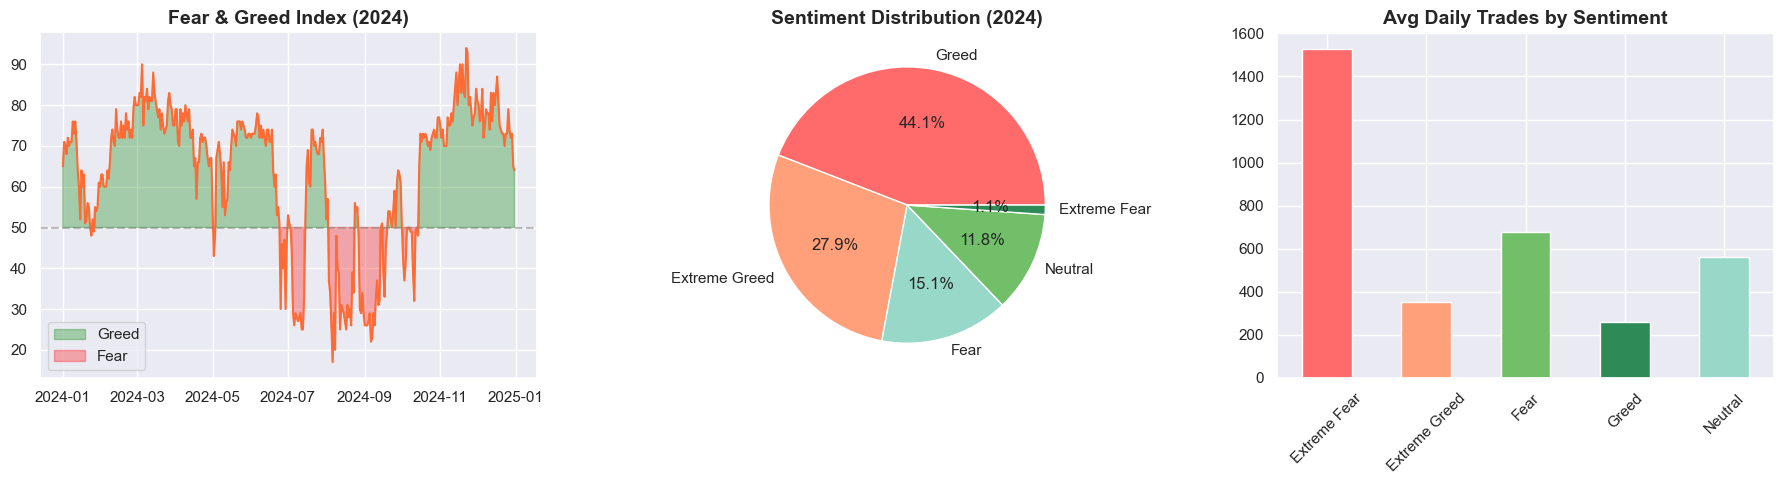


Part A complete! Data prepared and saved.


In [10]:
# Summary statistics by sentiment
print("=" * 60)
print("SUMMARY BY SENTIMENT CATEGORY")
print("=" * 60)
summary = daily_agg.groupby('sentiment').agg(
    days=('date', 'count'),
    avg_daily_pnl=('total_pnl', 'mean'),
    avg_daily_trades=('total_trades', 'mean'),
    avg_win_rate=('avg_win_rate', 'mean'),
    avg_trade_size=('avg_trade_size', 'mean'),
    avg_volume=('total_volume', 'mean'),
).round(2)
print(summary)

# FGI distribution visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fgi_2024 = fgi[(fgi['date'] >= '2024-01-01') & (fgi['date'] <= '2024-12-31')]
axes[0].plot(fgi_2024['date'], fgi_2024['fgi_value'], color='#FF6B35', linewidth=1.5)
axes[0].axhline(y=50, color='gray', linestyle='--', alpha=0.5)
axes[0].fill_between(fgi_2024['date'], fgi_2024['fgi_value'], 50, 
                      where=fgi_2024['fgi_value']>=50, alpha=0.3, color='green', label='Greed')
axes[0].fill_between(fgi_2024['date'], fgi_2024['fgi_value'], 50, 
                      where=fgi_2024['fgi_value']<50, alpha=0.3, color='red', label='Fear')
axes[0].set_title('Fear & Greed Index (2024)', fontsize=14, fontweight='bold')
axes[0].legend()

fgi_2024['sentiment'].value_counts().plot.pie(ax=axes[1], autopct='%1.1f%%', 
    colors=['#FF6B6B','#FFA07A','#98D8C8','#72BF6A','#2E8B57'])
axes[1].set_title('Sentiment Distribution (2024)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

daily_agg.groupby('sentiment')['total_trades'].mean().plot.bar(ax=axes[2], 
    color=['#FF6B6B','#FFA07A','#72BF6A','#2E8B57','#98D8C8'])
axes[2].set_title('Avg Daily Trades by Sentiment', fontsize=14, fontweight='bold')
axes[2].set_xlabel('')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('part_a_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPart A complete! Data prepared and saved.")

In [11]:
# Save processed data for subsequent notebooks
merged.to_csv('merged_data.csv', index=False)
daily_trader.to_csv('daily_trader_metrics.csv', index=False)
daily_agg.to_csv('daily_aggregate_metrics.csv', index=False)
print("Saved: merged_data.csv, daily_trader_metrics.csv, daily_aggregate_metrics.csv")

Saved: merged_data.csv, daily_trader_metrics.csv, daily_aggregate_metrics.csv
